# Normalisations and the structure of a covariance

Four datasets of one quartic, each with its own unknown normalisation.  Four
treatments of that normalisation: as a latent scale on the model, as a
correlated mode in the covariance, ignored, and ignored but with an inferred
model error.  Then a gallery of covariance *structures* and what each one
does to a posterior.

Recipes: 3, 6, 27

In [1]:
import corner
import emcee
import matplotlib.pyplot as plt
import numpy as np
from numpy.polynomial import polynomial as P
from scipy import stats
from sklearn.gaussian_process.kernels import RBF, ConstantKernel

import rxmc as rx
from rxmc import terms as T
from rxmc import transforms as tf

## Four datasets, four normalisations

The truth is a quartic.  Each experiment measures it on its own range with
its own noise, and multiplies everything by a normalisation `ρ_i` drawn
from a distribution of known width `σ_sys,i`, which it reports.  The realised
`ρ_i` are stored only so we can check the inference later.

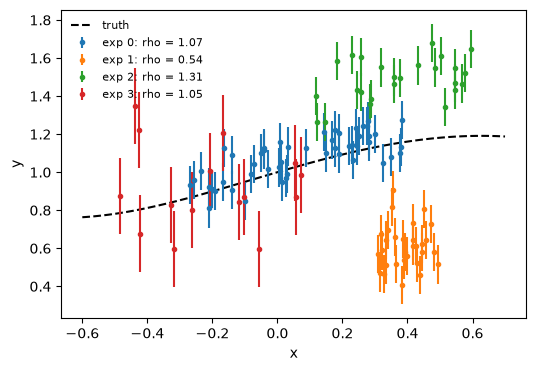

In [2]:
rng = np.random.default_rng(42)
a_true = np.array([1.0, 0.5, -0.1, -0.4, 0.1])
settings = [  # (domain, n, noise, sys_fraction)
    ((-0.3, 0.4), 50, 0.1, 0.1),
    ((0.3, 0.5), 30, 0.1, 0.5),
    ((0.1, 0.6), 25, 0.1, 0.2),
    ((-0.5, 0.1), 15, 0.2, 0.6),
]
datasets, rho_true, sys_fraction = [], [], []
for i, (domain, n, noise, sys) in enumerate(settings):
    x = np.sort(rng.uniform(*domain, n))
    rho = rng.normal(1.0, sys)
    y = rng.normal(P.polyval(x, a_true) * rho, noise)
    datasets.append(rx.Dataset(x, y, np.full(n, noise), norm_err=sys, label=f"exp {i}"))
    rho_true.append(rho)
    sys_fraction.append(sys)

x_fine = np.linspace(-0.6, 0.7, 100)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x_fine, P.polyval(x_fine, a_true), "k--", label="truth")
for d, rho in zip(datasets, rho_true):
    ax.errorbar(d.x, d.y, d.y_err, fmt="o", ms=3, label=f"{d.label}: rho = {rho:.2f}")
ax.set(xlabel="x", ylabel="y")
ax.legend(frameon=False, fontsize=8)
plt.show()

## The model and a tight prior on the constant term

An additive constant and a multiplicative normalisation are nearly
confounded on a short range, so the prior on `a0` is tight; the other
coefficients get wide priors.

In [3]:
coeffs = [rx.Parameter("a0", prior=stats.norm(1.0, 0.03), latex="a_0")] + [
    rx.Parameter(f"a{k}", prior=stats.norm(0.0, 1.0), latex=f"a_{k}")
    for k in range(1, 5)
]
quartic = rx.Model(lambda x, *a: P.polyval(np.asarray(x, dtype=float), a), coeffs)


def fit(problem, seed, n_walkers=32, n_steps=2500):
    sampler = emcee.EnsembleSampler(n_walkers, problem.ndim, problem.log_posterior)
    sampler.random_state = np.random.RandomState(seed).get_state()
    sampler.run_mcmc(problem.sample_prior(n_walkers, rng=seed), n_steps, progress=False)
    return sampler.get_chain(discard=n_steps // 3, thin=5, flat=True)


def curves(problem, samples, n=300):
    on_fine = quartic.bind(x_fine, {})
    cols = problem.columns(quartic.params)
    return np.array([on_fine(*s[cols]) for s in samples[-n:]])

## Four treatments of the normalisation

1. **Latent scale on the model** (recipe 6): `quartic | tf.scale(rho_i)`
   gives each comparison its own multiplicative parameter, sampled in log
   space with the reported width as its prior.
2. **Correlated mode in the covariance** (recipe 3): `T.normalization` with
   the reported magnitude, one per dataset, built from the prediction.  The
   `Dataset` carries `norm_err`, so `comp.reported_terms()` builds exactly
   this.
3. **Ignored**: reported statistics only.
4. **Ignored, with an inferred model error**: a diagonal `T.model_error`
   whose fraction is a free parameter, the honest-looking way to be wrong.

In [4]:
rhos = [
    rx.Parameter(
        f"log_rho_{i}", prior=stats.norm(0.0, np.log1p(s)), latex=rf"\log\rho_{i}"
    )
    for i, s in enumerate(sys_fraction)
]
comps_scaled = [rx.Comparison(d, quartic | tf.scale(r)) for d, r in zip(datasets, rhos)]
comps = [rx.Comparison(d, quartic) for d in datasets]
gamma = rx.Parameter(
    "log_gamma", prior=stats.norm(np.log(0.1), 0.5), latex=r"\log\gamma"
)

problems = {
    "latent scale": rx.Problem([rx.Constraint(comps_scaled)]),
    "normalisation mode": rx.Problem(
        [rx.Constraint(comps, terms=[t for c in comps for t in c.reported_terms()])]
    ),
    "ignored": rx.Problem([rx.Constraint(comps)]),
    "ignored + model error": rx.Problem(
        [rx.Constraint(comps, terms=[T.model_error(gamma, averaging=True)])]
    ),
}
for name, p in problems.items():
    print(f"{name:22s} columns: {p.names}")

latent scale           columns: ['a0', 'a1', 'a2', 'a3', 'a4', 'log_rho_0', 'log_rho_1', 'log_rho_2', 'log_rho_3']
normalisation mode     columns: ['a0', 'a1', 'a2', 'a3', 'a4']
ignored                columns: ['a0', 'a1', 'a2', 'a3', 'a4']
ignored + model error  columns: ['a0', 'a1', 'a2', 'a3', 'a4', 'log_gamma']


In [5]:
samples = {name: fit(p, seed=i) for i, (name, p) in enumerate(problems.items())}
colors = {
    "latent scale": "C0",
    "normalisation mode": "C1",
    "ignored": "C3",
    "ignored + model error": "C2",
}
for name, s in samples.items():
    cols = problems[name].columns(quartic.params)
    print(
        f"{name:22s} "
        + "  ".join(
            f"a{k}={s[:, c].mean():.2f}+/-{s[:, c].std():.2f}"
            for k, c in enumerate(cols)
        )
    )

latent scale           a0=1.01+/-0.03  a1=0.47+/-0.08  a2=0.19+/-0.30  a3=-1.05+/-0.54  a4=0.22+/-0.85
normalisation mode     a0=1.01+/-0.03  a1=0.47+/-0.09  a2=0.18+/-0.30  a3=-1.03+/-0.55  a4=0.28+/-0.83
ignored                a0=1.09+/-0.02  a1=0.11+/-0.08  a2=-2.17+/-0.27  a3=0.90+/-0.53  a4=6.00+/-0.84
ignored + model error  a0=0.99+/-0.03  a1=-0.08+/-0.17  a2=-0.73+/-0.40  a3=0.67+/-0.77  a4=1.06+/-0.93


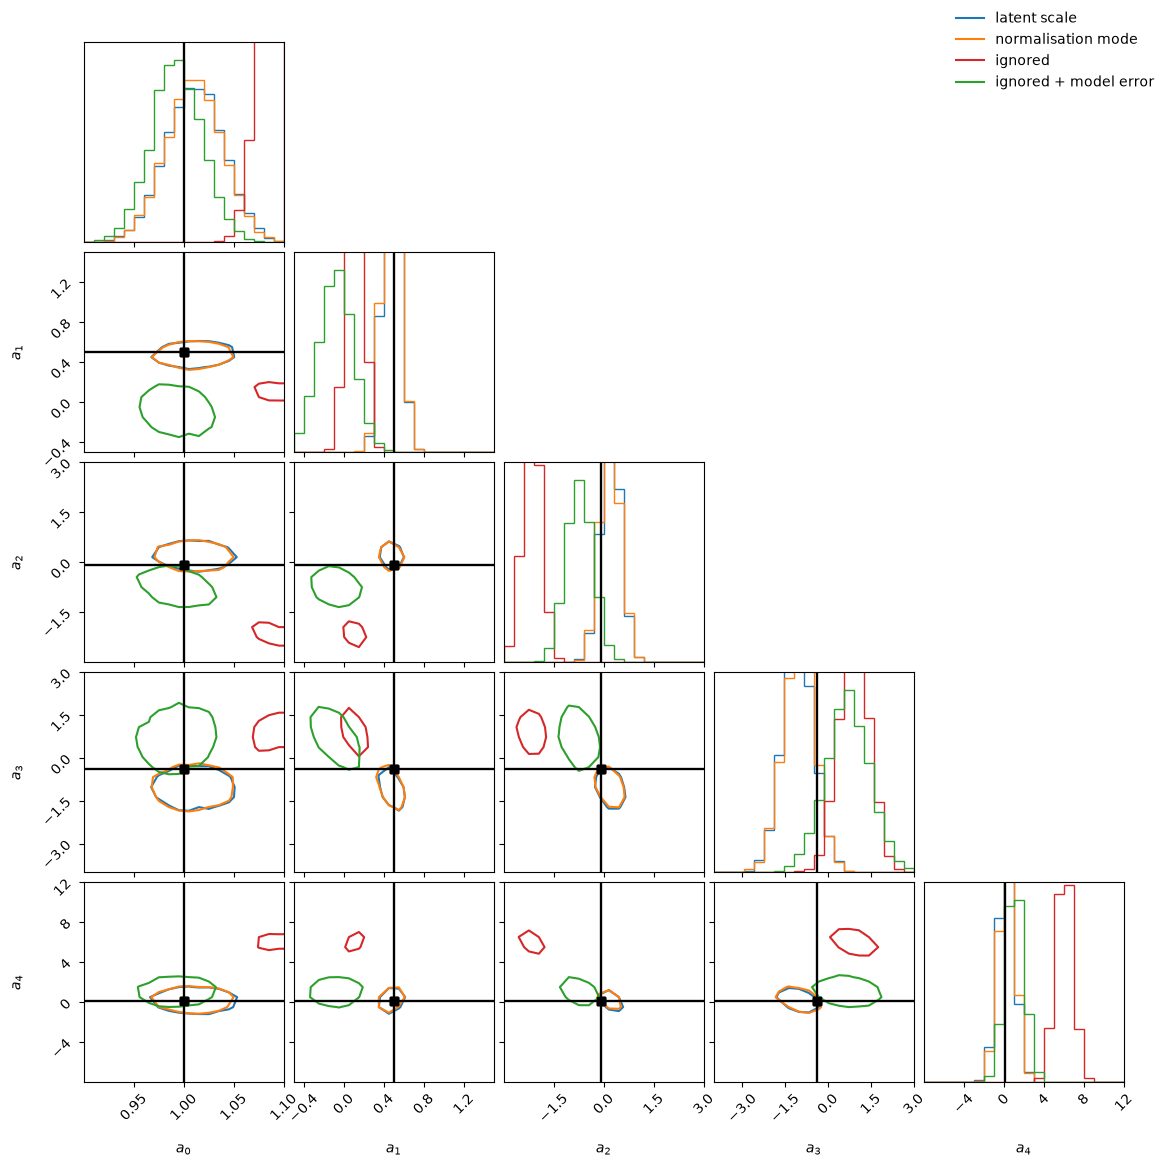

In [6]:
fig = None
for name, s in samples.items():
    fig = corner.corner(
        s[:, problems[name].columns(quartic.params)],
        fig=fig,
        color=colors[name],
        labels=[f"${p.latex}$" for p in quartic.params],
        truths=a_true,
        truth_color="k",
        plot_datapoints=False,
        plot_density=False,
        levels=(0.68,),
        range=[(0.9, 1.1), (-0.5, 1.5), (-3, 3), (-4, 3), (-8, 12)],
    )
fig.legend(
    handles=[plt.Line2D([], [], color=c, label=n) for n, c in colors.items()],
    loc="upper right",
    frameon=False,
)
plt.show()

The latent scale and the normalisation mode agree: they are the same
statistical model, one with the scale sampled and one with it marginalised
analytically (a Gaussian latent that multiplies the prediction is a rank-one
mode in the covariance).  The two treatments that ignore the normalisation
do not converge near the truth, and inflating the diagonal does not rescue
them: a common shift is not noise.

### The inferred normalisations

With the latent scale the `ρ_i` are columns of the chain.  Divide each
dataset by its posterior median scale and it should realign with the truth.

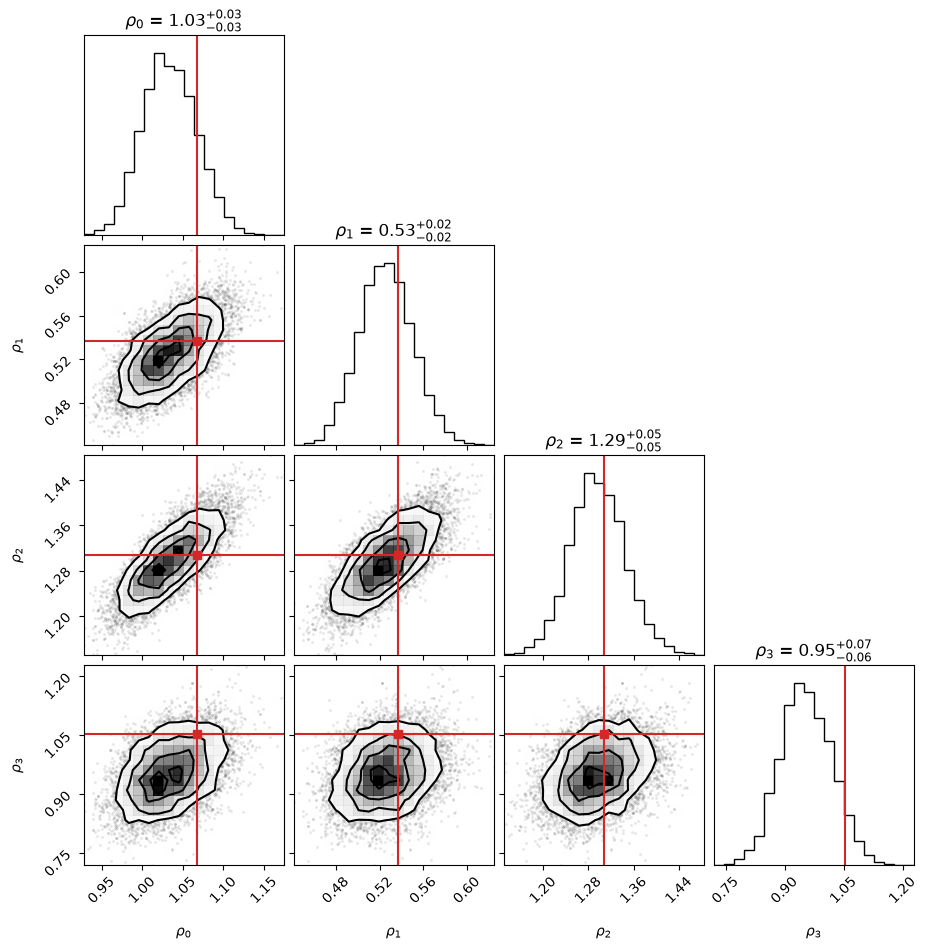

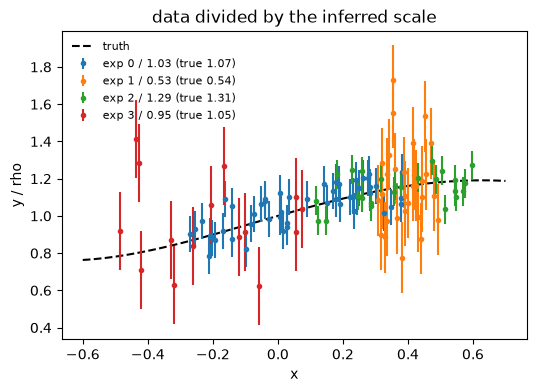

In [7]:
p_scaled, s_scaled = problems["latent scale"], samples["latent scale"]
rho_cols = p_scaled.columns(rhos)
fig = corner.corner(
    np.exp(s_scaled[:, rho_cols]),
    labels=[rf"$\rho_{i}$" for i in range(4)],
    truths=rho_true,
    truth_color="C3",
    show_titles=True,
)
plt.show()

rho_map = np.exp(np.median(s_scaled[:, rho_cols], axis=0))
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x_fine, P.polyval(x_fine, a_true), "k--", label="truth")
for d, rho, r_true in zip(datasets, rho_map, rho_true):
    ax.errorbar(
        d.x,
        d.y / rho,
        d.y_err / rho,
        fmt="o",
        ms=3,
        label=f"{d.label} / {rho:.2f} (true {r_true:.2f})",
    )
ax.set(xlabel="x", ylabel="y / rho", title="data divided by the inferred scale")
ax.legend(frameon=False, fontsize=8)
plt.show()

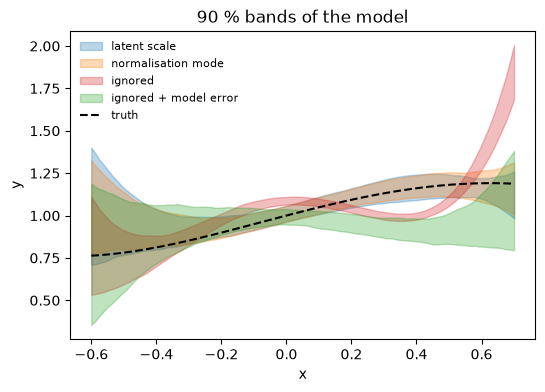

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
for name, s in samples.items():
    lo, hi = np.percentile(curves(problems[name], s), [5, 95], axis=0)
    ax.fill_between(x_fine, lo, hi, color=colors[name], alpha=0.3, label=name)
ax.plot(x_fine, P.polyval(x_fine, a_true), "k--", label="truth")
ax.set(xlabel="x", ylabel="y", title="90 % bands of the model")
ax.legend(frameon=False, fontsize=8)
plt.show()

## A gallery of covariance structures

Every term writes a pattern into Σ.  `constraint.matrix(theta)` returns the
assembled covariance at any parameter value, so the pattern can be drawn.

In [9]:
def correlation(S):
    d = np.sqrt(np.diag(S))
    return S / np.outer(d, d)


def show(ax, S, title, dividers=()):
    im = ax.imshow(correlation(S), cmap="RdBu_r", vmin=-1, vmax=1)
    for k in dividers:
        ax.axhline(k - 0.5, color="k", lw=0.5)
        ax.axvline(k - 0.5, color="k", lw=0.5)
    ax.set(title=title, xticks=[], yticks=[])
    return im


d0 = datasets[0]
theta_map = np.median(samples["normalisation mode"], axis=0)

### 1. A systematic correlated across x: flat mode versus smooth kernel

A normalisation is a rank-one mode: every pair of points is correlated by
the same fraction.  A Gaussian-process kernel correlates neighbours in `x`
and forgets across the range.  Both are one term.

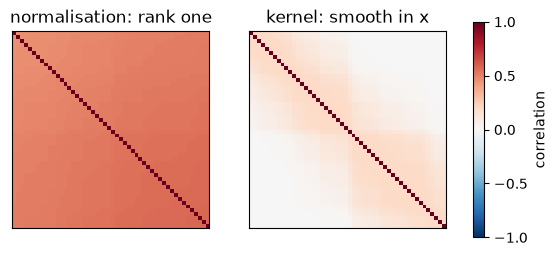

In [10]:
c_flat = rx.Constraint([comps[0]], terms=[T.normalization(magnitude=0.1)])
c_kernel = rx.Constraint(
    [comps[0]], terms=[T.kernel(ConstantKernel(0.05**2, "fixed") * RBF(0.15, "fixed"))]
)
fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))
p_flat, p_kernel = rx.Problem([c_flat]), rx.Problem([c_kernel])
show(
    axes[0],
    p_flat.constraints[0].matrix(theta_map[: p_flat.ndim]),
    "normalisation: rank one",
)
im = show(
    axes[1],
    p_kernel.constraints[0].matrix(theta_map[: p_kernel.ndim]),
    "kernel: smooth in x",
)
fig.colorbar(im, ax=axes, shrink=0.8, label="correlation")
plt.show()

### 2. Correlated statistical errors: bring the matrix, and do not diagonalise it

If the experiment reports a full statistical covariance, pass it as a fixed
`Term`.  Treating correlated noise as independent over-counts the
information: the naive posterior is visibly tighter than the correct one.

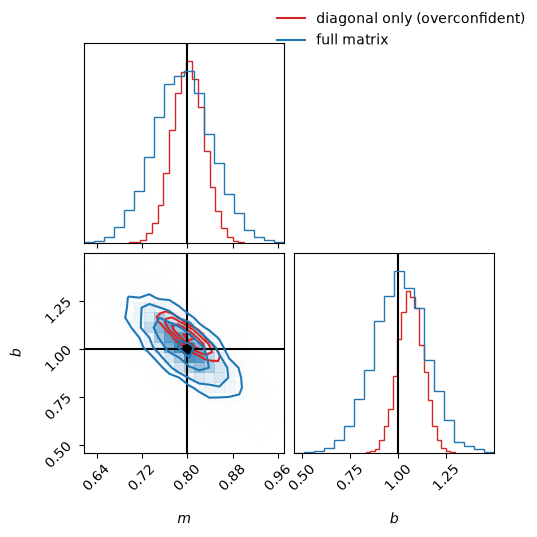

diagonal: m = 0.802 +/- 0.028   full: m = 0.793 +/- 0.051


In [11]:
xs = np.linspace(0.0, 4.0, 20)
C = 0.15**2 * np.exp(-np.abs(xs[:, None] - xs[None, :]) / 1.2)
a_line = np.array([1.0, 0.8])
y_corr = a_line[0] + a_line[1] * xs + rng.multivariate_normal(np.zeros(20), C)
d_corr = rx.Dataset(xs, y_corr, np.sqrt(np.diag(C)), label="correlated noise")
m_, b_ = rx.Parameter("m", prior=stats.norm(0, 5), latex="m"), rx.Parameter(
    "b", prior=stats.norm(0, 5), latex="b"
)
line = rx.Model(lambda x, m, b: b + m * x, [m_, b_])
c_full = rx.Constraint(
    [rx.Comparison(d_corr, line)], terms=[rx.Term(C, kind="matrix")], statistical=False
)
c_diag = rx.Constraint([rx.Comparison(d_corr, line)])
s_full, s_diag = fit(rx.Problem([c_full]), seed=11), fit(rx.Problem([c_diag]), seed=12)
fig = corner.corner(
    s_diag,
    color="C3",
    labels=["$m$", "$b$"],
    truths=[0.8, 1.0],
    truth_color="k",
    plot_datapoints=False,
)
corner.corner(s_full, fig=fig, color="C0", plot_datapoints=False)
fig.legend(
    handles=[
        plt.Line2D([], [], color="C3", label="diagonal only (overconfident)"),
        plt.Line2D([], [], color="C0", label="full matrix"),
    ],
    loc="upper right",
    frameon=False,
)
plt.show()
print(
    f"diagonal: m = {s_diag[:, 0].mean():.3f} +/- {s_diag[:, 0].std():.3f}   full: m = {s_full[:, 0].mean():.3f} +/- {s_full[:, 0].std():.3f}"
)

### 3. Unknown or misreported magnitudes

A `model_error` term scales with the prediction; its fraction sets how much
the total error exceeds what was reported.

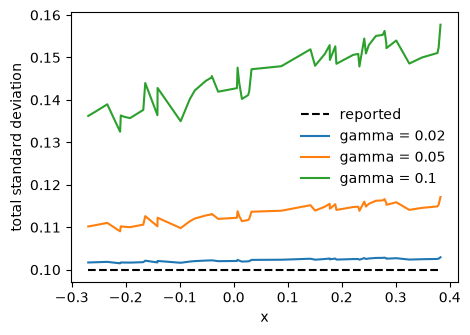

In [12]:
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(d0.x, d0.y_err, "k--", label="reported")
for g in (0.02, 0.05, 0.10):
    c = rx.Constraint([comps[0]], terms=[T.model_error(gamma, averaging=True)])
    p = rx.Problem([c])
    theta = np.append(theta_map[:5], np.log(g))
    ax.plot(
        d0.x, np.sqrt(np.diag(p.constraints[0].matrix(theta))), label=f"gamma = {g}"
    )
ax.set(xlabel="x", ylabel="total standard deviation")
ax.legend(frameon=False)
plt.show()

### 4. A systematic shared across datasets

The same normalisation term `on` two comparisons couples their blocks; one
per comparison leaves the covariance block diagonal.  Which is right depends
on whether the two experiments really shared the calibration; the next
notebook is about that choice.

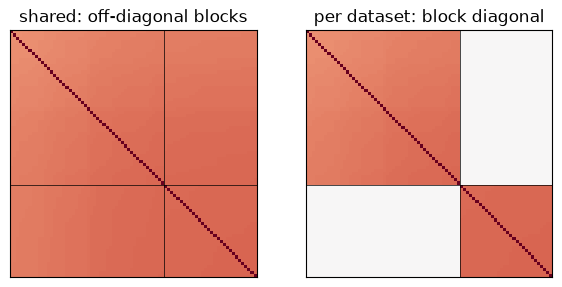

In [13]:
two = comps[:2]
c_shared = rx.Constraint(two, terms=[T.normalization(magnitude=0.1, on=two)])
c_each = rx.Constraint(two, terms=[T.normalization(magnitude=0.1, on=c) for c in two])
fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))
n0 = datasets[0].n
for ax, c, title in zip(
    axes,
    (c_shared, c_each),
    ("shared: off-diagonal blocks", "per dataset: block diagonal"),
):
    p = rx.Problem([c])
    show(ax, p.constraints[0].matrix(theta_map[:5]), title, dividers=(n0,))
plt.show()

## Summary

| case | term | structure of Σ |
|---|---|---|
| unknown normalisation, sampled | `model \| tf.scale(rho)` | none: the mean moves |
| reported normalisation | `T.normalization(magnitude=)` | rank one, from the prediction |
| smooth systematic in x | `T.kernel(...)` | dense, decaying with distance |
| reported correlated statistics | `rx.Term(C, kind="matrix")` | whatever was reported |
| unknown model error | `T.model_error(gamma)` | sampled diagonal |
| shared across datasets | one term `on=[c1, c2]` | off-diagonal blocks |

Declaring the uncertainty *is* the modelling choice; the inference machinery
is unchanged.  Never build a mode from the data (recipe 27): the prediction
is what the mode multiplies.